<a href="https://colab.research.google.com/github/junpia1123/BIPN-145/blob/main/LabChart/ImportingPython.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Importing LabChart (Python)

This notebook will help you import and plot *any* exported .txt file from LabChart.

<mark>To run this, you will need to upload an exported .txt file from LabChart into Colab. First, [export the channels you'd like to plot](https://bipn145.github.io/LabChart/ExportingLabChart.html). Then [upload the exported file it to Colab](https://bipn145.github.io/intro.html).</mark>

## Step 1. Setup

>**Task**: Run the cell below to import our necessary packages and configure the notebook environment.

In [2]:
# Import our packages
import matplotlib.pyplot as plt
import numpy as np

print('Packages imported.')

Packages imported.


## Step 2. Import data
Now that we have our notebook configured, we can import our data. We will import it as a numpy array.

To do so:

1. Upload your file into the same folder as this code.
2. Change the filename below to your filename.
3. Define a list of column names. If you exported one channel, you'll have just two columns, given as two strings in a list: `['time','recording']`. This is in the code by default. However, you should add a column name **if** you exported more than one channel. In other words, you could write `['time','recording_1','recording_2']`.

In [4]:
# Change the filename to EXACTLY match your file
filename = 'recording.txt'

# Load & check shape of file
try:
    data = np.genfromtxt(filename, dtype=float, skip_header=6, delimiter='\t',encoding = 'unicode_escape')
except FileNotFoundError:
    print('Your file was not found. Please make sure you\'ve uploaded it following these directions: ')
    print('https://bipn145.github.io/intro.html#uploading-data-to-colab')
except ValueError:
    print('It looks like your data is the wrong shape, did you export the CURRENT SELECTION only?')

if data.shape[1] == 2:
    time, recording = data[:,0], data[:,1]
    print('Stored file with two columns as recording & time.')
elif data.shape[1] == 3:
    time, recording = data[:,0], data[:,1]
    recording_2 = data[:,2]
    print('Stored file with two columns as recording_1, recording_2, & time.')
else:
    print('Invalid data file. Please upload a .txt file exported from LabChart with one or two channels.')

Stored file with two columns as recording & time.


## Modify axes units *(optional)*

LabChart data *should* export by volts and second by default. We can inspect the timestamps to see whether these are in milliseconds or seconds.

**Note**: Remember that if your data was collected at 40,000 Hz (40 kHz), this means that there is 1/40,000 (or 0.000025) seconds between each data point.

In [5]:
try:
    print('\nTime between each data point is:')
    print(time[1]-time[0],' seconds')
except NameError:
    print('You do not currently have a known time axis.')
    length = input('What is the length of your recording in seconds?')
    time = np.linspace(0,float(length)+1,len(recording))
    print(time)


Time between each data point is:
2.5e-05  seconds


Instead of showing the axes in seconds, you might choose to show it in milliseconds. To do so, we should multiply the entire array by 1000, to convert from **s** to **ms**. You can multiply arrays in Python by taking the original array, and writing an expression to multiple it. For example:

```
array_s = np.array([0.000 , 0.0010 , 0.0020 , 0.0030 ])
array_ms = array_s * 1000
```

> **Task**: Create an array of timestamps in milliseconds by multiplying `time` by 1000. Assign it to `timestamps_ms`. Check that this worked by printing `timestamps_ms`.

In [6]:
# Convert into ms here
timestamps_ms = ...

Now you should have a `timestamps_ms` variable that you can plot with below, if you'd like!

## Step 3. Plot data
The code below will plot your data using [`plt.plot()`](https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.plot.html). This function requires two inputs: x and y. When we're plotting recordings, typically this means x = time, and y = voltage. If you'd like to plot your timestamps in milliseconds, you'll need to replace `time` with `timestamps_ms`. You should also add x and y labels.

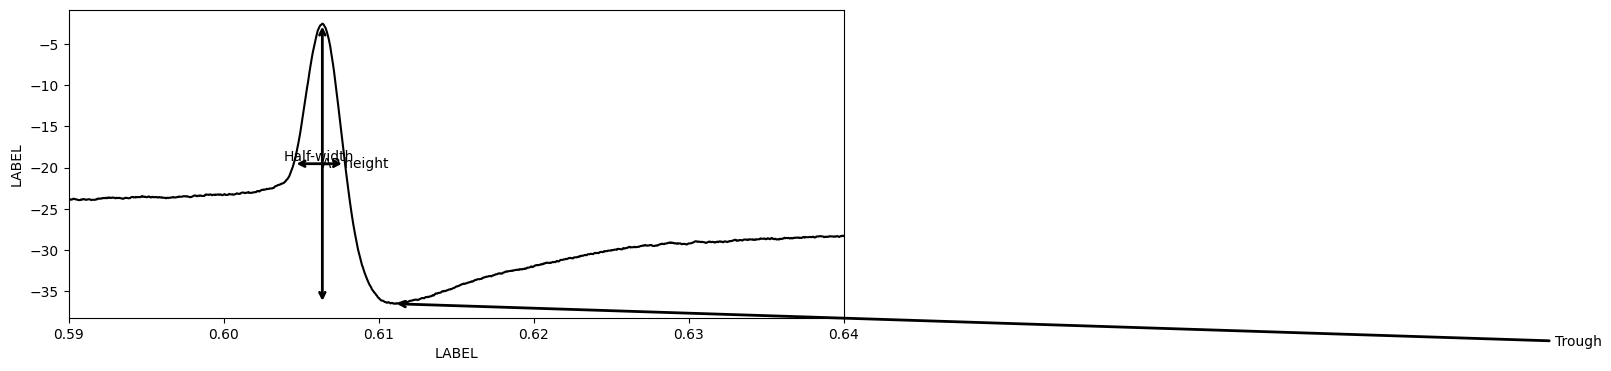

In [17]:
import numpy as np
import matplotlib.pyplot as plt

# -----------------------------
# Find peak, trough, half-height
# -----------------------------
peak_idx = np.argmax(recording)
trough_idx = np.argmin(recording)

peak_x, peak_y = time[peak_idx], recording[peak_idx]
trough_x, trough_y = time[trough_idx], recording[trough_idx]

half_height = (peak_y + trough_y) / 2

# ---------------------------------------
# Find half-width crossing points
# ---------------------------------------
above = recording > half_height
crossings = np.where(np.diff(above.astype(int)) != 0)[0]

left_idx = crossings[crossings < peak_idx][-1]
right_idx = crossings[crossings > peak_idx][0]

left_x = time[left_idx]
right_x = time[right_idx]

# -----------------------------
# Plot
# -----------------------------
fig, ax = plt.subplots(figsize=(10,4))
ax.plot(time, recording, color='black')

# -----------------------------
# Half-width arrow
# -----------------------------
ax.annotate(
    '',
    xy=(right_x, half_height),
    xytext=(left_x, half_height),
    arrowprops=dict(arrowstyle='<->', lw=2)
)

ax.text(
    (left_x + right_x) / 2,
    half_height,
    'Half-width',
    ha='center',
    va='bottom'
)

# -----------------------------
# Action potential height arrow
# -----------------------------
ax.annotate(
    '',
    xy=(peak_x, peak_y),
    xytext=(peak_x, trough_y),
    arrowprops=dict(arrowstyle='<->', lw=2)
)

ax.text(
    peak_x,
    (peak_y + trough_y) / 2,
    'AP height',
    ha='left',
    va='center'
)

# -----------------------------
# Arrow pointing to trough
# -----------------------------
ax.annotate(
    'Trough',
    xy=(trough_x, trough_y),
    xytext=(
        trough_x + 0.05 * (time[-1] - time[0]),
        trough_y - 0.15 * (peak_y - trough_y)
    ),
    arrowprops=dict(arrowstyle='->', lw=2)
)

# Labels & formatting
ax.set_xlabel('LABEL')
ax.set_ylabel('LABEL')
ax.ticklabel_format(useOffset=False, style='plain')

# Zoom x-axis from 0.4 to 0.8
ax.set_xlim(0.59, 0.64)

plt.show()



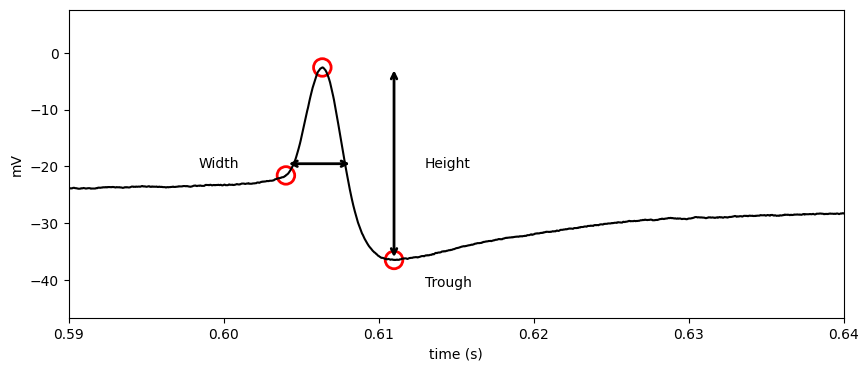

In [35]:
import numpy as np
import matplotlib.pyplot as plt

# -----------------------------
# Restrict analysis window
# -----------------------------
mask = (time >= 0.59) & (time <= 0.64)
t = time[mask]
v = recording[mask]

# -----------------------------
# Peak and trough
# -----------------------------
peak_idx = np.argmax(v)
trough_idx = np.argmin(v)

peak_x, peak_y = t[peak_idx], v[peak_idx]
trough_x, trough_y = t[trough_idx], v[trough_idx]

# -----------------------------
# Action potential onset (start of rise via dV/dt)
# -----------------------------
dv = np.gradient(v, t)
threshold = 0.2 * np.max(dv)
onset_idx = np.where(dv > threshold)[0][0]
onset_x, onset_y = t[onset_idx], v[onset_idx]

# -----------------------------
# Half-height & width
# -----------------------------
half_height = (peak_y + trough_y) / 2
above = v > half_height
crossings = np.where(np.diff(above.astype(int)) != 0)[0]

left_idx = crossings[crossings < peak_idx][-1]
right_idx = crossings[crossings > peak_idx][0]

left_x, right_x = t[left_idx], t[right_idx]

# -----------------------------
# Plot
# -----------------------------
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(t, v, color='black')
ax.margins(x=0.1, y=0.3)


# Width arrow (correct length)
# -----------------------------
# Use small extension equal to 1% of the x-range
x_ext = 0.01 * (t.max() - t.min())

ax.annotate(
    '',
    xy=(right_x + x_ext, half_height),
    xytext=(left_x - x_ext, half_height),
    arrowprops=dict(arrowstyle='<->', lw=2)
)

ax.text(
    left_x - x_ext - 0.003,
    half_height,
    'Width',
    ha='right',
    va='center'
)



# -----------------------------
# Height arrow (directly from trough)
# -----------------------------
x_offset = 0  # NO offset: starts exactly at trough

ax.annotate(
    '',
    xy=(trough_x, peak_y),
    xytext=(trough_x, trough_y),
    arrowprops=dict(arrowstyle='<->', lw=2)
)

ax.text(
    trough_x + 0.002,
    (peak_y + trough_y) / 2,
    'Height',
    va='center'
)

# -----------------------------
# Circles: onset, peak, trough
# -----------------------------
ax.scatter(
    [onset_x, peak_x, trough_x],
    [onset_y, peak_y, trough_y],
    s=160,
    facecolors='none',
    edgecolors='red',
    linewidths=2
)

# -----------------------------
# Labels (only onset + trough)
# -----------------------------

ax.text(
    trough_x + 0.002,                    # move right
    trough_y - 0.08 * (peak_y - trough_y),  # move down
    'Trough',
    ha='left',
    va='top',
    bbox=dict(boxstyle='round,pad=0.25', fc='white', ec='none', alpha=0.9)
)

# -----------------------------
# Formatting
# -----------------------------
ax.set_xlabel('time (s)')
ax.set_ylabel('mV')
ax.ticklabel_format(useOffset=False, style='plain')
ax.set_xlim(0.59, 0.64)

plt.show()


Once you've filled out this notebook, you can use this to plot *any* exported text file from LabChart, from earthworms, to leeches, and beyond!